# Measurement x=15, y=0, z=0

### Imports

In [211]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from python_utils.utils import load_object

from python_utils.time_series_extraction import find_closest_coordinate_index
from python_utils.time_series_extraction import plot_timeseries
from python_utils.data_processing import print_yz_slice_example_from_parsed_data

### General Args

In [212]:
# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 300

if Ha == 300:
    slice_folder_path = Path("../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates from evaluations
sigma = -1
B_z = -1

### Load Data

In [213]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [214]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
fld_data['index_to_coord_map'] = {
    idx: coord
    for coord, idx
    in fld_data['coord_to_index_map'].items()
    }
print_yz_slice_example_from_parsed_data(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
gradF_data['index_to_coord_map'] = {
    idx: coord
    for coord, idx
    in gradF_data['coord_to_index_map'].items()
    }
print_yz_slice_example_from_parsed_data(gradF_data)

The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 46, n_z (grid width) = 46, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 y, first 2 z) with coordinates:
  (y=-1.00, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.027423e-01  0.000000e+00
  0.000000e+00 -5.862112e-04  1.594463e+00]
  (y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.175437e-01  0.000000e+00
 -4.764620e-01 -5.860972e-04  1.599692e+00]
  (y=-0.99, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -1.220912e-01  2.072063e+00
  0.000000e+00 -5.841985e-04  1.580085e+00]
  (y=-0.99, z=-0.99): [ 2.256158e+00 -1.132797e-01  1.513446e-02 -2.226841e-01 -5.704941e-02
 -3.949543e-01 -5.842091e-04  1.584242e+00]

The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 46, n_z (grid width) = 46, n_v (number of variables) = 3
Labels:
['dfdx', 'dfdy', 'dfdz']
Preview of the first

### Get Existing x and y Coordinates

In [215]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_coord = y_coord_desired
# z_coord = z_coord_desired
if Ha == 300:
    y_coord = -0.01842125
    z_coord = -0.01842125
elif Ha == 1000:
    y_coord = 0
    z_coord = 0

i_y_center, i_z_center = find_closest_coordinate_index(
    fld_data['coord_to_index_map'],
    y_coord=y_coord,
    z_coord=z_coord,
    )

### Plot $v_x$

 x = streamwise

In [216]:
v_x_center = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('vx'):fld_data['labels'].index('vx') + 1,
    ]

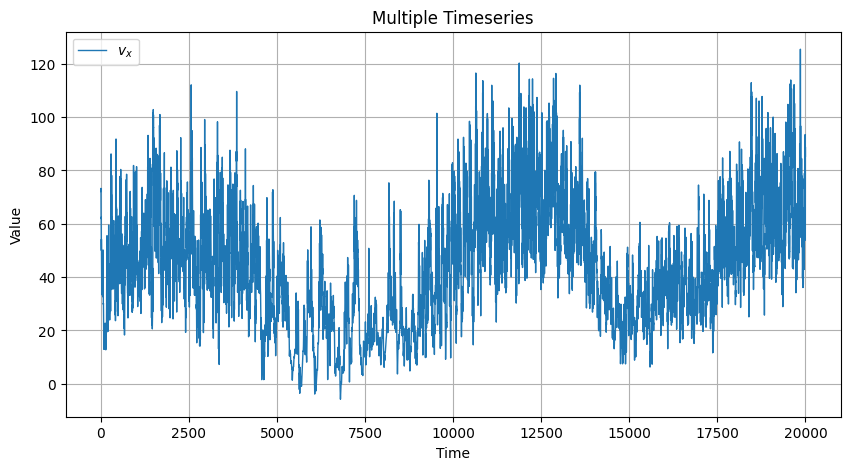

In [217]:
plot_timeseries(
    v_x_center,
    labels=["$v_{x}$"],
    )

### Ohm's Law

$\mathbf{J} = \sigma (\mathbf{E} + \mathbf{v} \times \mathbf{B})$

In vector form:

$\mathbf{J} = \begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \begin{pmatrix} E_x + (v_y B_z - v_z B_y) \\ E_y + (v_z B_x - v_x B_z) \\ E_z + (v_x B_y - v_y B_x) \end{pmatrix}$

We know that $B$ is only present in $z$-direction.

$\begin{pmatrix} j_x \\ j_y \\ j_z \end{pmatrix} = \sigma \left(\begin{pmatrix}E_x \\ E_y \\ E_z \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\partial \varphi}{\partial x} \\ \frac{\partial \varphi}{\partial y} \\ \frac{\partial \varphi}{\partial 
z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$\approx \sigma \left(\begin{pmatrix} \frac{\Delta \varphi_x}{\Delta l_x} \\ \frac{\Delta \varphi_y}{\Delta l_y} \\ \frac{\Delta \varphi_z}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

$= \sigma \left(\begin{pmatrix} \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \\ \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} \\ \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z} \end{pmatrix} + \begin{pmatrix}v_y B_z \\ -v_x B_z \\ 0 \end{pmatrix}\right)$

So, we have:

$ v_y \approx \frac{1}{B_z} \left( \frac{j_x}{\sigma} - \frac{\varphi_{x_2} - \varphi_{x_1}}{\Delta l_x} \right) $

$ v_x \approx \frac{1}{B_z} \left( \frac{\varphi_{y_2} - \varphi_{y_1}}{\Delta l_y} - \frac{j_y}{\sigma} \right) $

$ \frac{j_z}{\sigma} \approx \frac{\varphi_{z_2} - \varphi_{z_1}}{\Delta l_z}$

### Voltage (Potential Difference) $\Phi$

##### Real Voltage

This one can not be measured directly by the potential probe.

In [218]:
part_phi_y = gradF_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    gradF_data['labels'].index('dfdy'):gradF_data['labels'].index('dfdy') + 1,
    ]

##### Define Points $y_1$ and $y_2$

y_1_y = (y_1_y, y_1_z)

y_2_y = (y_2_y, y_2_z)

y_1_y < y_coord < y_2_y

y_1_z = z_coord = y_2_z

In [219]:
# """Coordinates by using delta_l
# """

# delta_l = 0.1  # y, z domain = [-1, 1]


# # Find y_1
# y_1_y_desired = y_coord - delta_l / 2
# y_1_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_1_y = y_1_y_desired
# # y_1_z = y_1_z_desired
# if Ha == 300:
#     y_1_y = -0.05560156
#     y_1_z = -0.01842125
# elif Ha == 1000:
#     y_1_y = -0.03460649
#     y_1_z = 0.0

# i_y_1_y, i_y_1_z = find_closest_coordinate_index(
#     fld_data['coord_to_index_map'],
#     y_coord=y_1_y,
#     z_coord=y_1_z,
#     )


# # Find y_2
# y_2_y_desired = y_coord + delta_l / 2
# y_2_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_2_y = y_2_y_desired
# # y_2_z = y_2_z_desired
# if Ha == 300:
#     y_2_y = 0.01842125
#     y_2_z = -0.01842125
# elif Ha == 1000:
#     y_2_y = 0.03460649
#     y_2_z = 0.0

# i_y_2_y, i_y_2_z = find_closest_coordinate_index(
#     fld_data['coord_to_index_map'],
#     y_coord=y_2_y,
#     z_coord=y_2_z,
#     )

In [220]:
"""Coordinates by using delta_i
"""

delta_i = 1


i_y_1_y = i_y_center - delta_i
i_y_1_z = i_z_center

i_y_2_y = i_y_center + delta_i
i_y_2_z = i_z_center

y_1_y, y_1_z = fld_data['index_to_coord_map'][i_y_1_y, i_y_1_z]
y_2_y, y_2_z = fld_data['index_to_coord_map'][i_y_2_y, i_y_2_z]

In [221]:
"""Coordinate Checkup
"""
print(f"Center: y = {fld_data['index_to_coord_map'][i_y_center, i_z_center]}, z = {fld_data['index_to_coord_map'][i_y_center, i_z_center]}")
print()
print(f"y_1 Coordinates: y = {y_1_y}, z = {y_1_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^y_1 = {y_1_y - y_coord}, delta_z^y_1 = {y_1_z - z_coord}, ", end='')
print(f"delta_i_y^y_1 = {i_y_1_y - i_y_center}, delta_i_z^y_1 = {i_y_1_z - i_z_center}")
print()
print(f"y_2 Coordinates: y = {y_2_y}, z = {y_2_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^y_2 = {y_2_y - y_coord}, delta_z^y_2 = {y_2_z - z_coord}, ", end='')
print(f"delta_i_y^y_2 = {i_y_2_y - i_y_center}, delta_i_z^y_2 = {i_y_2_z - i_z_center}")
print()
delta_y = y_2_y - y_1_y
delta_z = y_2_z - y_1_z
print(f"Difference between y_1 to y_2: ", end='')
print(f"delta_y = {delta_y}, delta_z = {delta_z}, ", end='')
print(f"delta_i_y = {i_y_2_y - i_y_1_y}, delta_i_z = {i_y_2_z - i_y_1_z}")

Center: y = (-0.01842125, -0.01842125), z = (-0.01842125, -0.01842125)

y_1 Coordinates: y = -0.05560156, z = -0.01842125
Difference to center: delta_y^y_1 = -0.03718031, delta_z^y_1 = 0.0, delta_i_y^y_1 = -1, delta_i_z^y_1 = 0

y_2 Coordinates: y = 0.01842125, z = -0.01842125
Difference to center: delta_y^y_2 = 0.0368425, delta_z^y_2 = 0.0, delta_i_y^y_2 = 1, delta_i_z^y_2 = 0

Difference between y_1 to y_2: delta_y = 0.07402281, delta_z = 0.0, delta_i_y = 2, delta_i_z = 0


##### Approx Voltage with Symmetric Difference Quotient

In [222]:
"""Approximate Voltage with Symmetric Difference Coefficient
"""

phi_y_1 = fld_data['timeseries'][
    :,
    i_y_1_y,
    i_y_1_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]
phi_y_2 = fld_data['timeseries'][
    :,
    i_y_2_y,
    i_y_2_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]

delta_phi_y = phi_y_2 - phi_y_1
approx_part_phi_y = delta_phi_y / delta_y

##### Compare Real with Approximate Voltage $\Phi$

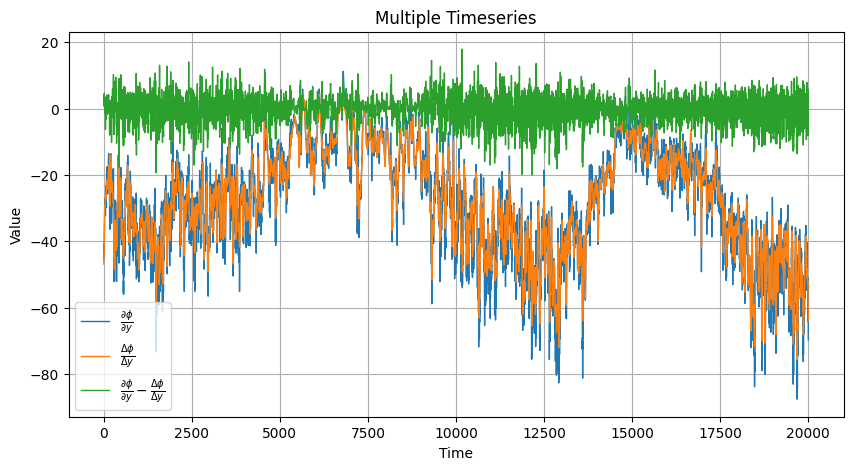

In [223]:
plot_timeseries(
    data_list=[
        part_phi_y,
        approx_part_phi_y,
        part_phi_y - approx_part_phi_y,
        ],
    labels=[
        "$\\frac{\\partial{\\phi}}{\\partial{y}}$",
        "$\\frac{\\Delta{\\phi}}{\\Delta{y}}$",
        "$\\frac{\\partial{\\phi}}{\\partial{y}} - \\frac{\\Delta{\\phi}}{\\Delta{y}}$"
        ],
    linewidth=1,
    )

### Plot $v_x^{pdm}$

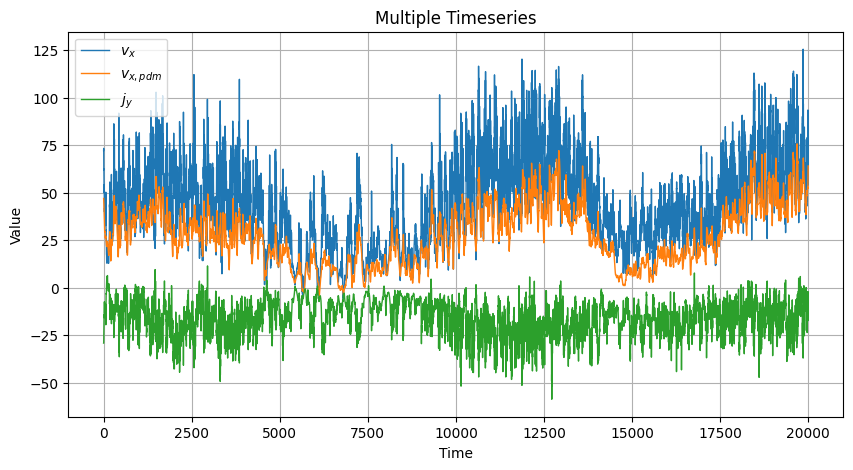

In [224]:
j_y_center = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('jy'):fld_data['labels'].index('jy') + 1,
    ]

v_x_pdm = approx_part_phi_y / B_z  # pdm = potential difference method

plot_timeseries(
    [
        v_x_center,
        v_x_pdm,
        j_y_center,
        ],
    labels=[
        "$v_{x}$",
        "$v_{x, pdm}$",
        "$j_{y}$",
        ],
    )

### Error Comparison

mse(ohm's law) = 7.977970680612163

mse(approx_law) = 28.609456222479967

mse(pdm) = 370.1846005621729

mse(c_pdm) = 127.45066125867902

mse(lr) = 107.0220717993754

covariance_matrix(v_x_pdm_norm, v_x_center_norm):
[[1.00005   0.8773056]
 [0.8773056 1.00005  ]]


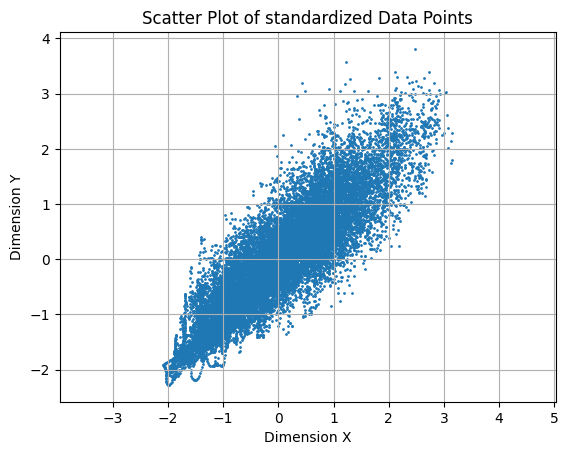

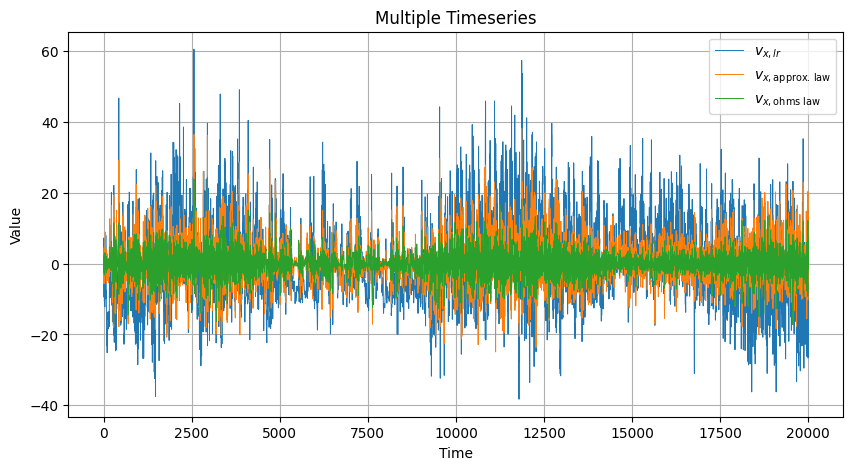

In [225]:
# known j_y + part_phi_y
v_x_ohms_law = (part_phi_y - (j_y_center / sigma)) / B_z
print(f"mse(ohm's law) = {mean_squared_error(v_x_center, v_x_ohms_law)}")
print()

# known j_y + approx_part_phi_y
v_x_approx_law = (approx_part_phi_y - (j_y_center / sigma)) / B_z
print(f"mse(approx_law) = {mean_squared_error(v_x_center, v_x_approx_law)}")
print()

# pdm
v_x_pdm = approx_part_phi_y / B_z  # pdm = potential difference method
print(f"mse(pdm) = {mean_squared_error(v_x_center, v_x_pdm)}")
print()

# pdm with c correction factor (= LR without bias)
model = LinearRegression(fit_intercept=False)
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
c =  1 / model.coef_[0, 0]
v_x_c_pdm = v_x_pdm / c
print(f"mse(c_pdm) = {mean_squared_error(v_x_center, v_x_c_pdm)}")
print()

# Linear Regression (LR)
model = LinearRegression()
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
v_x_lr = model.predict(v_x_pdm.reshape((-1, 1)))
print(f"mse(lr) = {mean_squared_error(v_x_center, v_x_lr)}")
print()

# Covariance
v_x_pdm_norm = (v_x_pdm - np.mean(v_x_pdm)) / np.std(v_x_pdm)
v_x_center_norm = (v_x_center - np.mean(v_x_center)) / np.std(v_x_center)
_data = np.concatenate((v_x_pdm_norm, v_x_center_norm), axis=1).T
covariance_matrix = np.cov(_data)
print("covariance_matrix(v_x_pdm_norm, v_x_center_norm):")
print(covariance_matrix)
plt.scatter(
    v_x_pdm_norm,
    v_x_center_norm,
    s=1,
    )
plt.title('Scatter Plot of standardized Data Points')
plt.xlabel('Dimension X')
plt.ylabel('Dimension Y')
plt.grid(True)
plt.axis('equal')  # Equal scaling for both axes
plt.show()

plot_timeseries(
    [
        # v_x_center - v_x_pdm,
        # v_x_center - v_x_c_pdm,
        v_x_center - v_x_lr,
        v_x_center - v_x_approx_law,
        v_x_center - v_x_ohms_law,
        ],
    labels=[
        # "v_x_pdm",
        # "v_x_c_lr",
        "$v_{x, lr}$",
        "$v_{x,\\text{approx. law}}$",
        "$v_{x, \\text{ohms law}}$",
        ],
    linewidth=0.7,
    )

##### Without Voltage Approximation

mse(ohm's law) = 7.977970680612163

mse(pdm) = 332.1348498632144

mse(c_pdm) = 103.84325393274713

mse(lr) = 76.98128415582886

covariance_matrix(v_x_pdm_norm, v_x_center_norm):
[[1.00005    0.91342626]
 [0.91342626 1.00005   ]]


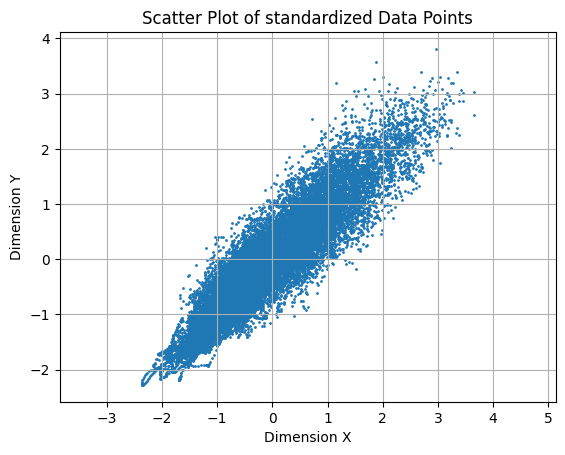

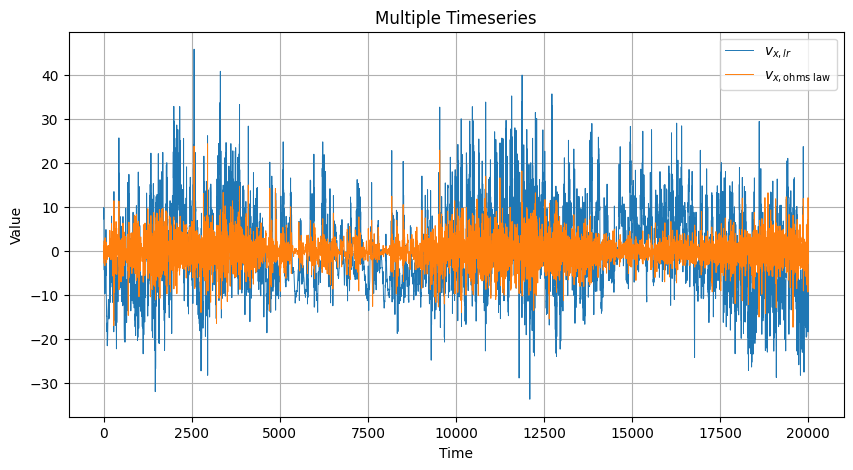

In [226]:
# known j_y + part_phi_y
v_x_ohms_law = (part_phi_y - (j_y_center / sigma)) / B_z
print(f"mse(ohm's law) = {mean_squared_error(v_x_center, v_x_ohms_law)}")
print()

# pdm
v_x_pdm = part_phi_y / B_z  # pdm = potential difference method
print(f"mse(pdm) = {mean_squared_error(v_x_center, v_x_pdm)}")
print()

# pdm with c correction factor (= LR without bias)
model = LinearRegression(fit_intercept=False)
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
c =  1 / model.coef_[0, 0]
v_x_c_pdm = v_x_pdm / c
print(f"mse(c_pdm) = {mean_squared_error(v_x_center, v_x_c_pdm)}")
print()

# Linear Regression (LR)
model = LinearRegression()
model.fit(
    X = v_x_pdm.reshape((-1, 1)),
    y = v_x_center.reshape((-1, 1)),
    )
v_x_lr = model.predict(v_x_pdm.reshape((-1, 1)))
print(f"mse(lr) = {mean_squared_error(v_x_center, v_x_lr)}")
print()

# Covariance
v_x_pdm_norm = (v_x_pdm - np.mean(v_x_pdm)) / np.std(v_x_pdm)
v_x_center_norm = (v_x_center - np.mean(v_x_center)) / np.std(v_x_center)
_data = np.concatenate((v_x_pdm_norm, v_x_center_norm), axis=1).T
covariance_matrix = np.cov(_data)
print("covariance_matrix(v_x_pdm_norm, v_x_center_norm):")
print(covariance_matrix)
plt.scatter(
    v_x_pdm_norm,
    v_x_center_norm,
    s=1,
    )
plt.title('Scatter Plot of standardized Data Points')
plt.xlabel('Dimension X')
plt.ylabel('Dimension Y')
plt.grid(True)
plt.axis('equal')  # Equal scaling for both axes
plt.show()

plot_timeseries(
    [
        # v_x_center - v_x_pdm,
        # v_x_center - v_x_c_pdm,
        v_x_center - v_x_lr,
        v_x_center - v_x_ohms_law,
        ],
    labels=[
        # "v_x_pdm",
        # "v_x_c_lr",
        "$v_{x, lr}$",
        "$v_{x, \\text{ohms law}}$",
        ],
    linewidth=0.7,
    )

### Comparing $\frac{\Delta{\phi}}{\Delta{y}}$ and $j_y$

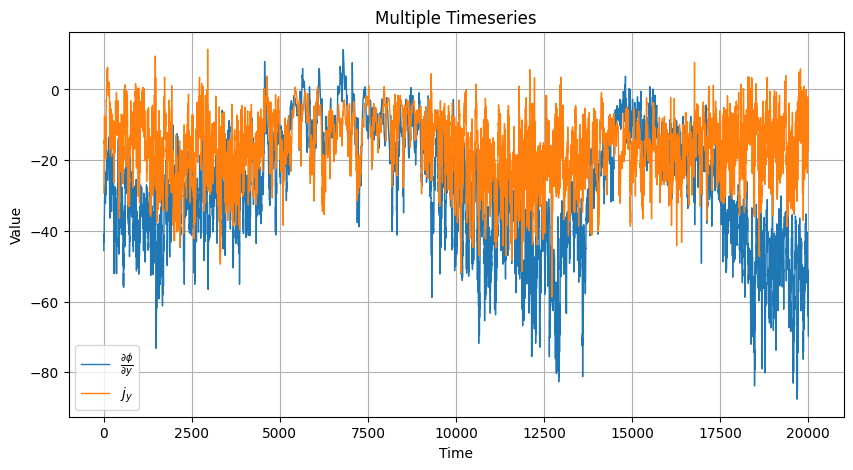

In [227]:
plot_timeseries(
    [
        part_phi_y,
        j_y_center,
        ],
    labels=[
        "$\\frac{\\partial{\\phi}}{\\partial{y}}$",
        "$j_{y}$",
        ],
    linewidth=1,
    )

## Ohm's Law in z-coord

### Voltage (Potential Difference) $\Phi$

##### Real Voltage

This one can not be measured directly by the potential probe.

In [228]:
part_phi_z = gradF_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    gradF_data['labels'].index('dfdz'):gradF_data['labels'].index('dfdz') + 1,
    ]

##### Approx Voltage with Symmetric Difference Quotient

In [229]:
"""Coordinates by using delta_i
"""

delta_i = 1


i_z_1_y = i_y_center
i_z_1_z = i_z_center - delta_i

i_z_2_y = i_y_center
i_z_2_z = i_z_center + delta_i

z_1_y, z_1_z = fld_data['index_to_coord_map'][i_z_1_y, i_z_1_z]
z_2_y, z_2_z = fld_data['index_to_coord_map'][i_z_2_y, i_z_2_z]

In [230]:
"""Coordinate Checkup
"""
print(f"Center: y = {fld_data['index_to_coord_map'][i_y_center, i_z_center]}, z = {fld_data['index_to_coord_map'][i_y_center, i_z_center]}")
print()
print(f"z_1 Coordinates: y = {z_1_y}, z = {z_1_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^z_1 = {z_1_y - y_coord}, delta_z^z_1 = {z_1_z - z_coord}, ", end='')
print(f"delta_i_y^z_1 = {i_z_1_y - i_y_center}, delta_i_z^z_1 = {i_z_1_z - i_z_center}")
print()
print(f"z_2 Coordinates: y = {z_2_y}, z = {z_2_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^z_2 = {z_2_y - y_coord}, delta_z^z_2 = {z_2_z - z_coord}, ", end='')
print(f"delta_i_y^z_2 = {i_z_2_y - i_y_center}, delta_i_z^z_2 = {i_z_2_z - i_z_center}")
print()
delta_y = z_2_y - z_1_y
delta_z = z_2_z - z_1_z
print(f"Difference between z_1 to z_2: ", end='')
print(f"delta_y = {delta_y}, delta_z = {delta_z}, ", end='')
print(f"delta_i_y = {i_z_2_y - i_z_1_y}, delta_i_z = {i_z_2_z - i_z_1_z}")

Center: y = (-0.01842125, -0.01842125), z = (-0.01842125, -0.01842125)

z_1 Coordinates: y = -0.01842125, z = -0.05560156
Difference to center: delta_y^z_1 = 0.0, delta_z^z_1 = -0.03718031, delta_i_y^z_1 = 0, delta_i_z^z_1 = -1

z_2 Coordinates: y = -0.01842125, z = 0.01842125
Difference to center: delta_y^z_2 = 0.0, delta_z^z_2 = 0.0368425, delta_i_y^z_2 = 0, delta_i_z^z_2 = 1

Difference between z_1 to z_2: delta_y = 0.0, delta_z = 0.07402281, delta_i_y = 0, delta_i_z = 2


In [231]:
"""Approximate Voltage with Symmetric Difference Coefficient
"""
phi_z_1 = fld_data['timeseries'][
    :,
    i_z_1_y,
    i_z_1_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]
phi_z_2 = fld_data['timeseries'][
    :,
    i_z_2_y,
    i_z_2_z,
    fld_data['labels'].index('F'):fld_data['labels'].index('F') + 1,
    ]

delta_phi_z = phi_z_2 - phi_z_1
approx_part_phi_z = delta_phi_z / delta_z

##### Compare Real with Approximate Voltage $\Phi$

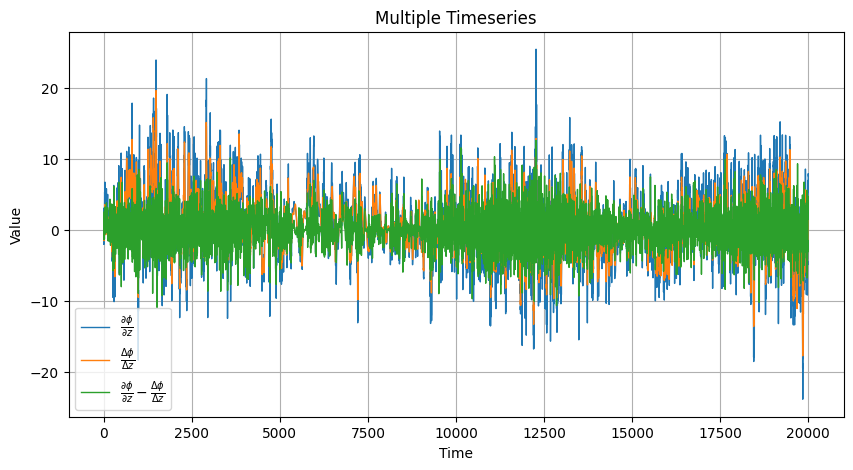

In [232]:
plot_timeseries(
    data_list=[
        part_phi_z,
        approx_part_phi_z,
        part_phi_z - approx_part_phi_z,
        ],
    labels=[
        "$\\frac{\\partial{\\phi}}{\\partial{z}}$",
        "$\\frac{\\Delta{\\phi}}{\\Delta{z}}$",
        "$\\frac{\\partial{\\phi}}{\\partial{z}} - \\frac{\\Delta{\\phi}}{\\Delta{z}}$"
        ],
    linewidth=1,
    )

### Error in z

In [233]:
j_z_center = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('jz'):fld_data['labels'].index('jz') + 1,
    ]

print(f"mse(part_phi_z) = {mean_squared_error(part_phi_z, j_z_center / sigma)}")

# plot_timeseries(
#     data_list=[
#         # part_phi_z,
#         part_phi_z - j_z_center / sigma_est_round,
#         ],
#     labels=[
#         # "$\\frac{\\partial{\\phi}}{\\partial{z}}$",
#         "err",
#         ],
#     linewidth=0.7,
#     )

mse(part_phi_z) = 5.858277161518981e-07
